In [25]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, Markdown

In [27]:
pain_points = pd.read_csv('challenges&expectations/pain_points.csv')
expectations = pd.read_csv('challenges&expectations/expectations.csv')

In [ ]:
def get_pain_points(keyword, optional_keywords=None, sentiment=None):
    """
    Get pain points based on keywords.

    Parameters:
    keyword (str or list): The main keyword or keywords to search for in the pain points.
    optional_keywords (list, optional): List of additional keywords to search for.
    sentiment (str, optional): The sentiment to filter by.

    Returns:
    DataFrame: Filtered DataFrame containing pain points that match the keywords.
    """
    keywords = keyword if isinstance(keyword, list) else [keyword]
    if optional_keywords:
        keywords.extend(optional_keywords)

    filtered_pain_points = pain_points[pain_points['processed_content'].str.contains('|'.join(keywords), case=False, na=False)]
    if sentiment is not None:
        filtered_pain_points = filtered_pain_points[filtered_pain_points['label'] == sentiment]
    return filtered_pain_points

# 1. System Usability & Performance

In [29]:
IPS_crashes = get_pain_points(['IPS'], optional_keywords=['crash', 'crashing','freezing', 'lag', 'slow', 'unresponsive', 'stuck', 'hang', 'freeze', 'navigat', 'interface', 'in-field', 'infield', 'in field', 'dashboard'], sentiment='negative') 
print(f"Total number of pain points related to IPS crashing issues: {len(IPS_crashes)}")

Total number of pain points related to IPS crashing issues: 13


In [30]:
if IPS_crashes.empty:
    print("No matching pain points found.")
else:
    IPS_crashes.sample(min(5, len(IPS_crashes)))

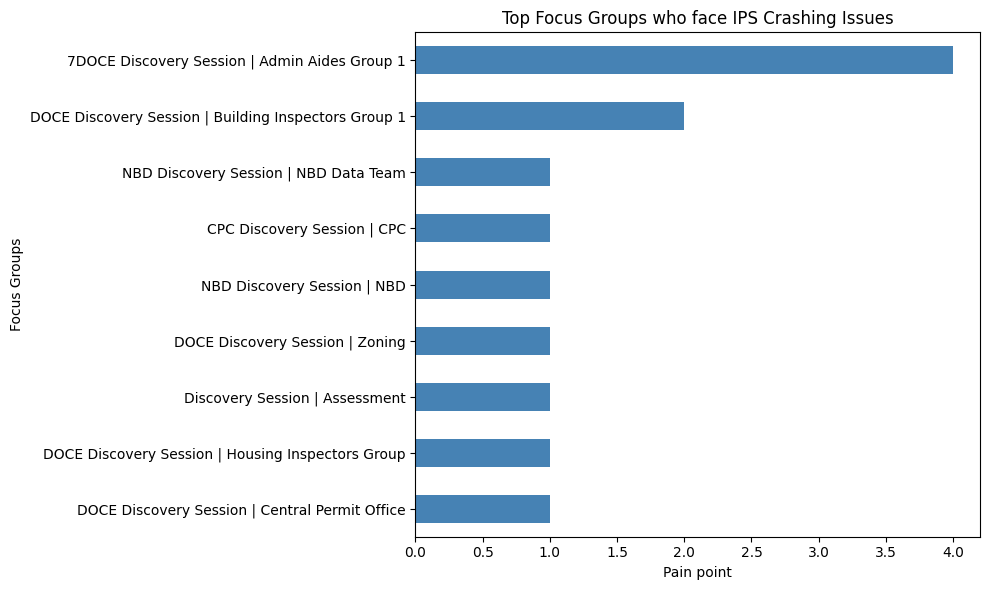

In [31]:

if IPS_crashes.empty:
    print("No matching pain points found.")
else:
    top_ips_crashes = IPS_crashes["Focus Group"].value_counts()

    plt.figure(figsize=(10, 6))
    top_ips_crashes.sort_values().plot(kind="barh", color="steelblue")
    plt.title("Top Focus Groups who face IPS Crashing Issues")
    plt.xlabel("Pain point")
    plt.ylabel("Focus Groups")
    plt.tight_layout()
    plt.show()

# 2. Multiple Systems: Fragmented Data

In [32]:
multiple_systems = get_pain_points(['tool','system'], optional_keywords=['too many', 'multiple', 'various', 'different', 'diverse', 'several', 'numerous', 'countless', 'abundant', 'plenty'], sentiment='negative')
print(f"Total number of pain points related to multiple systems: {len(multiple_systems)}")

Total number of pain points related to multiple systems: 16


In [33]:
if multiple_systems.empty:
    print("No matching pain points found.")
else:
    multiple_systems.sample(5)

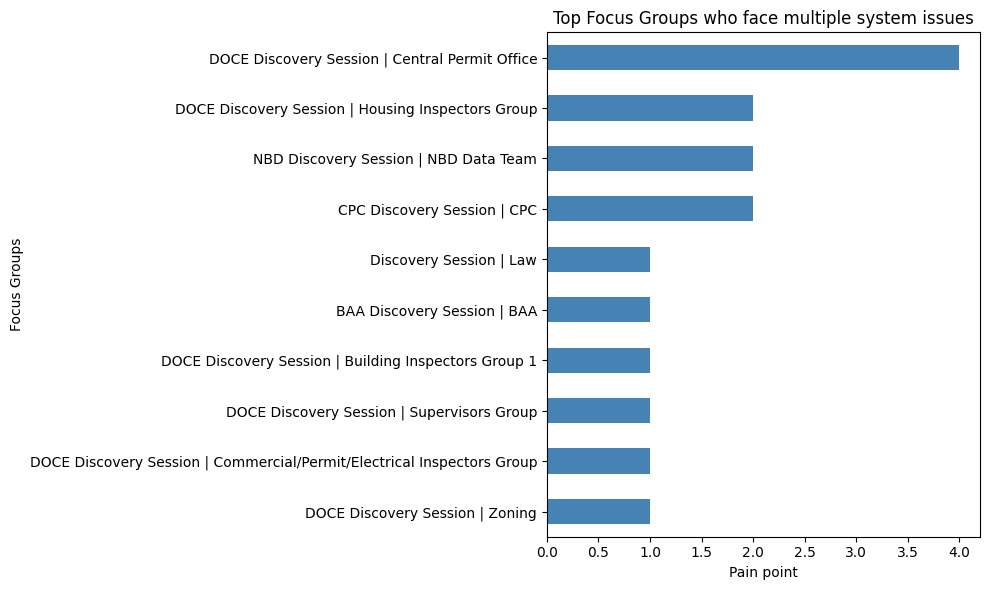

In [34]:
if multiple_systems.empty:
    print("No matching pain points found.")
else:
    multiple_sys = multiple_systems["Focus Group"].value_counts()

    plt.figure(figsize=(10, 6))
    multiple_sys.sort_values().plot(kind="barh", color="steelblue")
    plt.title("Top Focus Groups who face multiple system issues")
    plt.xlabel("Pain point")
    plt.ylabel("Focus Groups")
    plt.tight_layout()
    plt.show()

# 3. Property Research Difficulties

In [35]:
property_research = get_pain_points(['search', 'research'], optional_keywords=['ownership', 'deed search', 'ownership', 'parcel'], sentiment='negative') 
print(f"Total number of pain points related to property research: {len(property_research)}")

Total number of pain points related to property research: 14


In [36]:
if property_research.empty:
    print("No matching pain points found.")
else:
    property_research.sample(min(5, len(property_research)))

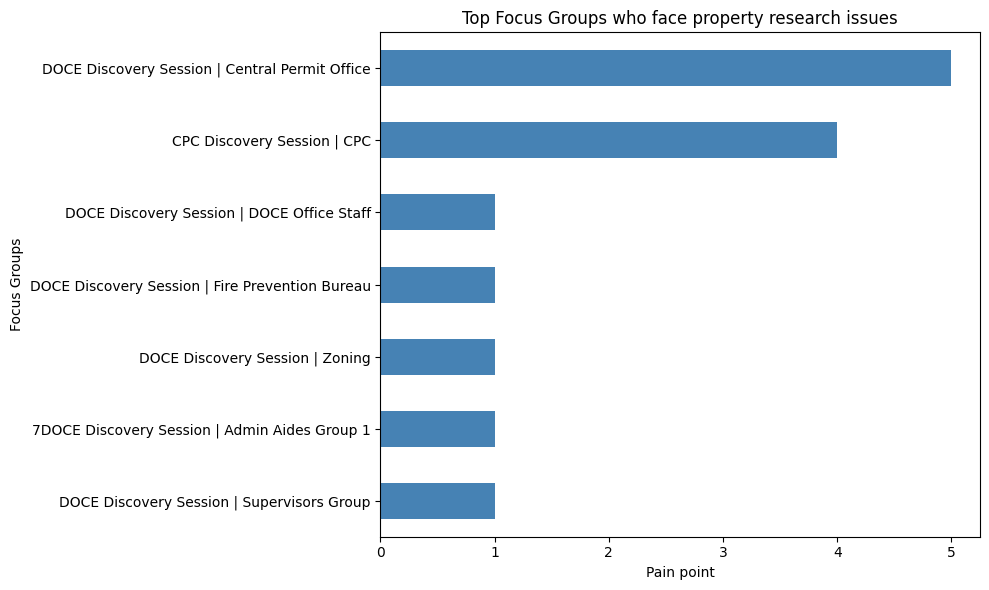

In [37]:
if property_research.empty:
    print("No matching pain points found.")
else:
    property_research_sys = property_research["Focus Group"].value_counts()

    plt.figure(figsize=(10, 6))
    property_research_sys.sort_values().plot(kind="barh", color="steelblue")
    plt.title("Top Focus Groups who face property research issues")
    plt.xlabel("Pain point")
    plt.ylabel("Focus Groups")
    plt.tight_layout()
    plt.show()

# 4. Integration Issues

In [38]:
integration = get_pain_points(['integrate', 'integrat'], optional_keywords=['dont talk to each other', 'doesnt talk to each other', 'dont communicate with each other'])
print(f"Total number of pain points related to integration issues: {len(integration)}")

Total number of pain points related to integration issues: 1


# 5. Limited Search Capabilities

In [39]:
limited_search_capabilities = get_pain_points(['IPS', 'search'], optional_keywords=['limited','limitation', 'find', 'lookup'])
print(f"Total number of pain points related to limited search capabilities: {len(limited_search_capabilities)}")

Total number of pain points related to limited search capabilities: 19


In [40]:
if limited_search_capabilities.empty:
    print("No matching pain points found.")
else:
    limited_search_capabilities.sample(min(5, len(limited_search_capabilities)))

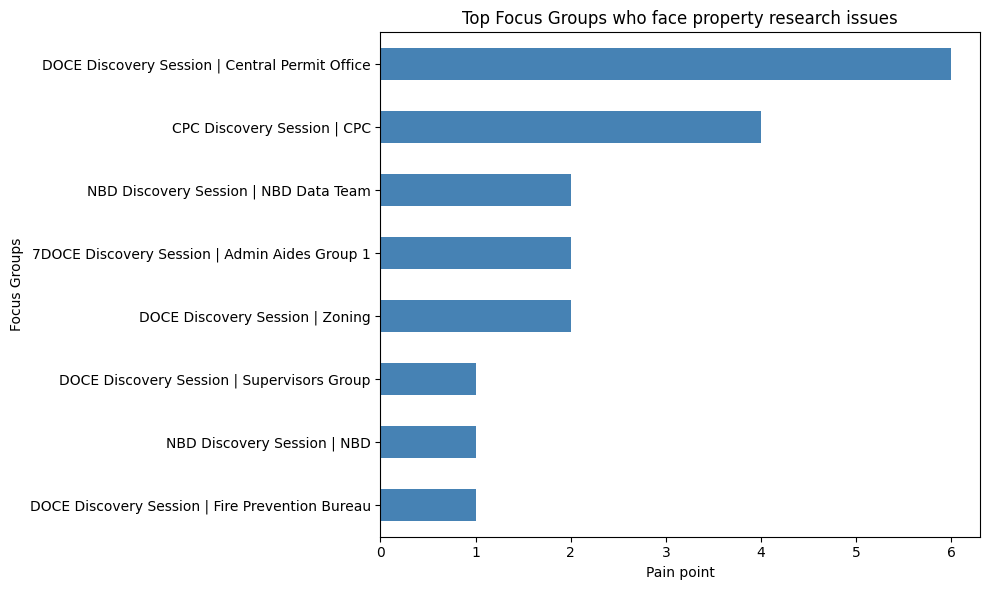

In [41]:
if limited_search_capabilities.empty:
    print("No matching pain points found.")
else:
    limited_search_capabilities_sys = limited_search_capabilities["Focus Group"].value_counts()

    plt.figure(figsize=(10, 6))
    limited_search_capabilities_sys.sort_values().plot(kind="barh", color="steelblue")
    plt.title("Top Focus Groups who face property research issues")
    plt.xlabel("Pain point")
    plt.ylabel("Focus Groups")
    plt.tight_layout()
    plt.show()

In [42]:
case_management = get_pain_points(['case management'], optional_keywords=['case', 'management', 'cases', 'manage', 'managing', 'handled', 'handling'])
print(f"Total number of pain points related to case management: {len(case_management)}")

Total number of pain points related to case management: 33


# Scattered Plot Diagram

In [43]:
# Interactive scatter plot with focus groups on the y-axis
series = [
    (IPS_crashes, "IPS Crashing Issues", "#e74c3c", -0.15),
    (multiple_systems, "Multiple Systems Issues", "#3498db", 0.00),
    (property_research, "Property Research Issues", "#2ecc71", 0.15),
    (integration, "Integration Issues", "#f39c12", 0.30),
    (limited_search_capabilities, "Limited Search Capabilities", "#9b59b6", 0.45),
    (case_management, "Case Management Issues", "#fffb0a", 0.60)
]

counts = {label: data["Focus Group"].value_counts() for data, label, _, _ in series}
focus_groups = sorted(
    {group for count in counts.values() for group in count.index},
    key=lambda group: sum(count.get(group, 0) for count in counts.values()),
    reverse=True,
)
focus_groups = [group for group in focus_groups if any(count.get(group, 0) for count in counts.values())]
y_positions = {group: index for index, group in enumerate(focus_groups)}
max_x = max(7, max((count.max() for count in counts.values() if not count.empty), default=0))

fig = go.FigureWidget()
output = widgets.Output()

for data, label, color, offset in series:
    count = data["Focus Group"].value_counts()
    groups = [group for group in focus_groups if count.get(group, 0) > 0]
    values = [count.get(group, 0) for group in groups]
    trace = fig.add_scatter(
        x=values,
        y=[y_positions[group] + offset for group in groups],
        mode="markers",
        name=label,
        marker=dict(size=14, color=color, line=dict(color="white", width=1)),
        customdata=np.array(groups),
        hovertemplate="<b>%{customdata}</b><br>Count=%{x}<extra>" + label + "</extra>",
    )

    def show_details(trace, points, selector, data=data, label=label):
        if not points.point_inds:
            return
        group = trace.customdata[points.point_inds[0]]
        selected = data[data["Focus Group"] == group][["Focus Group", "Content", "label"]].head(10).reset_index(drop=True)
        with output:
            output.clear_output(wait=True)
            display(Markdown(f"### {label}"))
            display(Markdown(f"**Focus Group:** {group}"))
            display(selected.style.set_properties(subset=["Content"], **{"width": "900px", "white-space": "pre-wrap"}))

    # attach click handler to the recently added trace
    fig.data[-1].on_click(show_details)

fig.update_layout(
    title="Focus Groups With Pain Points",
    xaxis_title="Number of Pain Points",
    yaxis=dict(tickmode="array", tickvals=list(y_positions.values()), ticktext=focus_groups),
    template="plotly_white",
    height=750,
    width=1200,
    legend_title_text="",
    margin=dict(l=220, r=40, t=70, b=60),
)
fig.update_xaxes(dtick=1, range=[0.8, max_x + 0.2])

widgets.VBox([fig, output])

    'data': [{'customdata': array(['DOCE Discovery Session | Central Permit Offi…